# Análise de Teste A/B e Priorização de Hipóteses para Otimização de Receita

Nome: Fabrício Camacho

Data: 26/01/2026

## Objetivos
O presente projeto tem como objetivo criar estratégias para aumentar a receita de uma loja online. Para tanto, temos os seguintes objetivos específicos, divididos em duas partes:

<b>PARTE 1</b>

- Aplicar o framework ICE para priorizar hipóteses, classificando-as em ordem decrescente de prioridade;
- Aplicar o framework RICE para priorizar hipóteses, classificando-as em ordem decrescente de prioridade;
- Mostrar como a priorização de hipóteses muda quando você usa RICE em vez de ICE e dar uma explicação para as alterações. 

<b>PARTE 2</b>

Análise completa de um teste A/B, incluindo:
- Gráficos de receita acumulada e tamanho médio de pedido acumulado por grupo.
- Gráfico da diferença relativa no tamanho médio de pedido entre grupos.
- Cálculo e plotagem das taxas de conversão diárias.
- Análise de anomalias em pedidos por usuário e preços de pedidos (percentis 95 e 99).
- Testes de significância estatística para diferença na conversão e tamanho médio de pedido (dados brutos e filtrados).
- Decisão clara sobre o teste A/B (parar e considerar líder, parar e concluir sem diferença, ou continuar).

## Estruturação do projeto

- Carregamento e Visão Geral dos Dados: Carregar hypotheses_us.csv, orders_us.csv, visits_us.csv em DataFrames Pandas e inspecionar.
- Pré-processamento dos Dados: Padronizar nomes de colunas (snake_case), converter datas para datetime, tratar valores ausentes, remover usuários em ambos os grupos A/B.
- Priorização de Hipóteses: Calcular pontuações ICE e RICE, classificar hipóteses, comparar resultados e explicar diferenças (foco no "Alcance").
- Preparação de Dados para Análise A/B: Criar DataFrame unificado com dados cumulativos diários (visitas, pedidos, receita) por grupo.
- Análise Gráfica do Teste A/B: Plotar receita acumulada, tamanho médio acumulado do pedido, diferença relativa do tamanho médio do pedido, taxa de conversão diária acumulada.
- Análise de Anomalias: Calcular percentis 95 e 99 para número de pedidos por usuário e preços de pedidos para definir limites de anomalias.
- Testes de Significância Estatística: Realizar teste Mann-Whitney U para conversão e tamanho médio de pedido (dados brutos e filtrados).
- Tomada de Decisão Final: Formular recomendação clara com base em todas as análises.

## Carregamento e Pré-processamento de Dados
### Importando bibliotecas


In [1]:
# Importando bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats


### Carregando os Datasets.

In [2]:
# Carregando o conjunto de dados
df_hypothesis = pd.read_csv('datasets/hypotheses_us.csv', sep=';')
df_orders = pd.read_csv('datasets/orders_us.csv')
df_visits = pd.read_csv('datasets/visits_us.csv')


### Inspeção Inicial dos Dados

In [3]:
# Impriminto informações básicas dos dados
print("Informações do DataFrame de Hipóteses:")
print(df_hypothesis.info())
print()
print(df_hypothesis.head())
print()
print("\nInformações do DataFrame de Pedidos:")
print(df_orders.info())
print()
print(df_orders.head())
print()
print("\nInformações do DataFrame de Visitas:")
print(df_visits.info())
print()
print(df_visits.head())


Informações do DataFrame de Hipóteses:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes
None

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3

### Padronização de Nomes de Colunas
Renomear colunas para snake_case (`df_hypotheses`, `df_orders`, `df_visits`)

In [4]:
# Alterando nomes das colunas em df_hypoptheses para padrão snake_case
df_hypothesis.columns = df_hypothesis.columns.str.lower()
df_orders.columns = df_orders.columns.str.lower()
df_visits.columns = df_visits.columns.str.lower()

# Verificando resultados
print(df_hypothesis.info())
print()
print(df_orders.info())
print()
print(df_visits.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionid  1197 non-null   int64  
 1   visitorid      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data c

### Correção de Tipos de Dados
Converter colunas de data para `datetime`

In [5]:
# Alterando colunas de df_orders e df_visitors que possuem datas para padrão datetime.
dfs_with_dates = [df_orders, df_visits]

# Criando loop para converter colunas "date"
for df in dfs_with_dates:
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        
# Checando resultados
print(df_orders.info())
print()
print(df_visits.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionid  1197 non-null   int64         
 1   visitorid      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB
None


### Verificação de Duplicatas e Usuários em Ambos os Grupos A/B
   - Identificar e remover usuários em ambos os grupos
   - Verificar e remover duplicatas em `orders` e `visits`

In [6]:
# Agrupando por visitorid e contando quantos grupos únicos cada um tem
visitors_in_both_groups = df_orders.groupby('visitorid').agg({'group': 'nunique'})

# Filtrando apenas aqueles que possuem 2 grupos (A e B)
duplicate_visitors = visitors_in_both_groups[visitors_in_both_groups['group'] > 1].index

print(f"Quantidade de usuários em ambos os grupos: {len(duplicate_visitors)}")
print(duplicate_visitors)


Quantidade de usuários em ambos os grupos: 58
Index([   8300375,  199603092,  232979603,  237748145,  276558944,  351125977,
        393266494,  457167155,  471551937,  477780734,  818047933,  963407295,
       1230306981, 1294878855, 1316129916, 1333886533, 1404934699, 1602967004,
       1614305549, 1648269707, 1668030113, 1738359350, 1801183820, 1959144690,
       2038680547, 2044997962, 2378935119, 2458001652, 2579882178, 2587333274,
       2600415354, 2654030115, 2686716486, 2712142231, 2716752286, 2780786433,
       2927087541, 2949041841, 2954449915, 3062433592, 3202540741, 3234906277,
       3656415546, 3717692402, 3766097110, 3803269165, 3891541246, 3941795274,
       3951559397, 3957174400, 3963646447, 3972127743, 3984495233, 4069496402,
       4120364173, 4186807279, 4256040402, 4266935830],
      dtype='int64', name='visitorid')


Há 58 visitantes que participaram tanto do grupo A quanto do grupo B. Dessa maneira, é necessário retirar os dados desses visitantes para que as análises sejam fidedignas.

In [7]:
# Filtrando o dataframe mantendo apenas os visitorid que NÃO estão em duplicate_visitors
df_orders_cleaned = df_orders[~df_orders['visitorid'].isin(duplicate_visitors)]

# Verificar quantas linhas foram removidas
linhas_removidas = len(df_orders) - len(df_orders_cleaned)
print(f"Linhas removidas: {linhas_removidas}")
print(f"Novo tamanho do dataframe: {len(df_orders_cleaned)}")


Linhas removidas: 181
Novo tamanho do dataframe: 1016


## PARTE 1: Priorizando Hipóteses
Aqui vamos aplicar dois frameworks para priorizar hipóteses: ICE e RICE. O objetivo é aplica-los e compara-los posteriormente, analisando suas diferenças. Para melhor visualização, seguem as hipótesis existentes no df_hypotheses:

- Add two new channels for attracting traffic. This will bring 30% more users;
- Launch your own delivery service. This will shorten delivery time;
- Add product recommendation blocks to the store's site. This will increase conversion and average purchase size;
- Change the category structure. This will increase conversion since users will find the products they want more quickly;
- Change the background color on the main page. This will increase user engagement;
- Add a customer review page. This will increase the number of orders;
- Show banners with current offers and sales on the main page. This will boost conversion;
- Add a subscription form to all the main pages. This will help you compile a mailing list;
- Launch a promotion that gives users discounts on their birthdays.


In [8]:
# Calculando ICE e inserindo resultados em uma coluna
df_hypothesis['ice_score'] = (df_hypothesis['impact'] * df_hypothesis['confidence']) / df_hypothesis['effort']
df_hypothesis['rice_score'] = (df_hypothesis['reach'] * df_hypothesis['impact'] * df_hypothesis['confidence']) / df_hypothesis['effort']

# Ordenando os resultados em ordem decrescente de ICE e RICE
ice_results = df_hypothesis.sort_values(by='ice_score', ascending=False).reset_index(drop=True)
rice_results = df_hypothesis.sort_values(by='rice_score', ascending=False).reset_index(drop=True)

# Rankeando os resultados em ordem decrescente de ICE e RICE
ice_results['rank_ice'] = range(1, len(ice_results) + 1)
rice_results['rank_rice'] = range(1, len(rice_results) + 1)

# Juntando os resultados em uma única tabela
final_result = df_hypothesis.merge(ice_results[['hypothesis', 'rank_ice']], on='hypothesis')
final_result = final_result.merge(rice_results[['hypothesis', 'rank_rice']], on='hypothesis')

# Imprimindo resultados
print('COMPARAÇÃO ICE VS RICE')
print('='* 120)
final_result


COMPARAÇÃO ICE VS RICE


,hypothesis,reach,impact,confidence,effort,ice_score,rice_score,rank_ice,rank_rice
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333,40.0,2,3
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000,4.0,6,7
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000,56.0,5,2
3,Change the category structure. This will incre...,8,3,3,8,1.125000,9.0,8,6
4,Change the background color on the main page. ...,3,1,1,1,1.000000,3.0,9,9
5,Add a customer review page. This will increase...,3,2,2,3,1.333333,4.0,7,8
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000,40.0,4,4
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000,112.0,3,1
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000,16.2,1,5


<b>Explicação:</b>

O framework ICE tem o foco na eficiência e prioriza as hipóteses com base no retorno por unidade de esforço, porém possui a limitação de não considerar a quantidade de pessoas afetadas. Já o framework RICE tem foco no impacto gerado no público alcançado e prioriza hipoteses que afetam mais usuários.

Devido a natureza diferente dos frameworks, a decisão deve ser tomada com base nos objetivos e no retorno esperado: ser o retorno focar na eficiência (ICE) ou no impacto gerado no público (RICE).

## PARTE 2: Análise do Teste A/B
### Preparação dos Dados Acumulados
Criar DataFrame com dados cumulativos diários de pedidos, visitantes, receita e visitas por grupo.

In [9]:
# Construindo um vetor com valores de pares unívocos de grupos de datas
dates_groups = df_orders_cleaned[['date', 'group']].drop_duplicates()

# Agregando os dados
orders_aggregated = dates_groups.apply(
  lambda x: df_orders_cleaned[np.logical_and(
    df_orders_cleaned['date'] <= x['date'], df_orders_cleaned['group'] == x['group'])]
  .agg({
    'date': 'max',
    'group': 'max',
    'transactionid': pd.Series.nunique,
    'visitorid': pd.Series.nunique,
    'revenue': 'sum',}),
  axis=1).sort_values(by=['date', 'group'])

visits_aggregated = dates_groups.apply(
  lambda x: df_visits[np.logical_and(
    df_visits['date'] <= x['date'], df_visits['group'] == x['group'])]
  .agg({
    'date': 'max',
    'group': 'max',
    'visits': 'sum'}),
  axis=1).sort_values(by=['date', 'group'])

# Criando dados cumulativos
cumulative_data = orders_aggregated.merge(
  visits_aggregated,
  left_on=['date', 'group'],
  right_on=['date', 'group'])

# Renomeando colunas da tabela de dados cumulativos
cumulative_data.columns = [
  'date',
  'group',
  'transactions',
  'visitors',
  'revenue',
  'visits']

# Adicionando coluna com média de receita (soma de receita dividido pelo número de transações) por data
cumulative_data['average_revenue'] = cumulative_data['revenue'] / cumulative_data['transactions']

# Adicionando coluna com média de transações (soma de transações dividido pelo número de visitantes) por data
cumulative_data['average_transactions'] = cumulative_data['transactions'] / cumulative_data['visitors']

# Calculando taxa de conversão
cumulative_data['conversion'] = cumulative_data['transactions'] / cumulative_data['visits']

cumulative_data.head()


,date,group,transactions,visitors,revenue,visits,average_revenue,average_transactions,conversion
0,2019-08-01,A,23,19,2266.6,719,98.547826,1.210526,0.031989
1,2019-08-01,B,17,17,967.2,713,56.894118,1.000000,0.023843
2,2019-08-02,A,42,36,3734.9,1338,88.926190,1.166667,0.031390
3,2019-08-02,B,40,39,3535.3,1294,88.382500,1.025641,0.030912
4,2019-08-03,A,66,60,5550.1,1845,84.092424,1.100000,0.035772


Criando dataframes de dados cumulativos por grupo para receita, receita média, pedidos, visitantes e visitas.

In [10]:
# Criando valores cumulativos de receita por grupo
cumulative_revenueA = cumulative_data[cumulative_data['group'] == 'A'][['date', 'revenue', 'transactions']]
cumulative_revenueB = cumulative_data[cumulative_data['group'] == 'B'][['date', 'revenue', 'transactions']]

# Criando valores médios cumulativos de receita por grupo
cumulative_average_revenueA = cumulative_data[cumulative_data['group'] == 'A'][['date', 'average_revenue']]
cumulative_average_revenueB = cumulative_data[cumulative_data['group'] == 'B'][['date', 'average_revenue']]

# Criando valores cumulativos de pedidos por grupo
cumulative_transactionsA = cumulative_data[cumulative_data['group'] == 'A'][['date', 'transactions']]
cumulative_transactionsB = cumulative_data[cumulative_data['group'] == 'B'][['date', 'transactions']]

# Criando valores cumulativos de visitantes por grupo
cumulative_visitoresA = cumulative_data[cumulative_data['group'] == 'A'][['date', 'visitors']]
cumulative_visitoresB = cumulative_data[cumulative_data['group'] == 'B'][['date', 'visitors']]

# Criando valores cumulativos de visitas por grupo
cumulative_visitsA = cumulative_data[cumulative_data['group'] == 'A'][['date', 'visits']]
cumulative_visitsB = cumulative_data[cumulative_data['group'] == 'B'][['date', 'visits']]

# Criando valores cumulativos de taxa de conversão por grupo
cumulative_conversionA = cumulative_data[cumulative_data['group'] == 'A'][['date', 'conversion']]
cumulative_conversionB = cumulative_data[cumulative_data['group'] == 'B'][['date', 'conversion']]


### Receita Acumulada por grupo
Aqui vamos plotar a receita acumulada por grupo e verificar as variações.

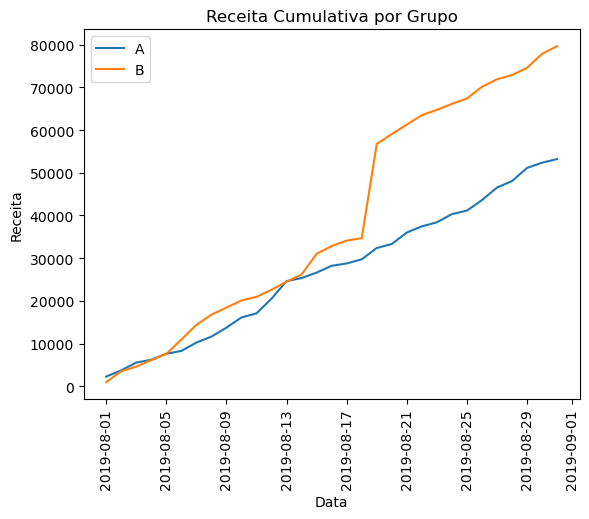

In [11]:
# Criando gráfico de receita cumulativa por grupo
plt.plot(cumulative_revenueA['date'], cumulative_revenueA['revenue'], label='A')
plt.plot(cumulative_revenueB['date'], cumulative_revenueB['revenue'], label='B')
plt.legend()
plt.title('Receita Cumulativa por Grupo')
plt.xlabel('Data')
plt.ylabel('Receita')
plt.xticks(rotation=90)
plt.show()


Observações: A receita apresenta um crescimento estável até o dia 17/08/2019. Neste desse dia, o grupo B apresenta um pico de receita e depois segue em crescimento estável em um patamar acima do grupo A. Este pico de receita apresentado pelo grupo B pode sugerir tanto uma alta na quantidade de pedidos como também a presença de pedidos muito caros na amostra.
Vamos analisar graficamente a receita média acumulada por grupo e entender melhor as variação entre os grupos.

### Tamanho Médio Acumulado do Pedido
Vamos plotar o tamanho médio acumulado do pedido e analisar variações.

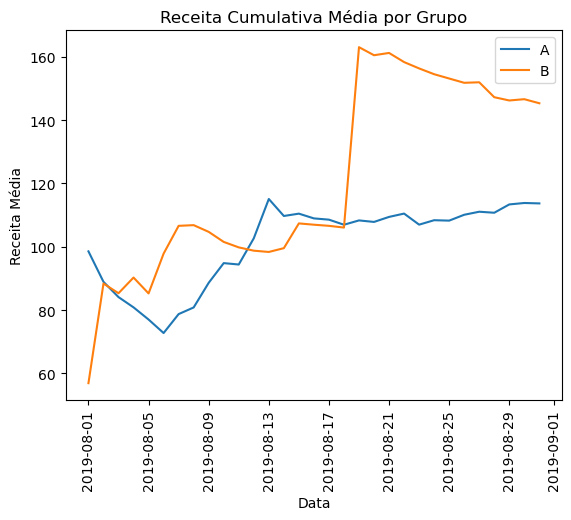

In [12]:
# Criando gráfico de receita cumulativa média
plt.plot(cumulative_average_revenueA['date'], cumulative_average_revenueA['average_revenue'], label='A')
plt.plot(cumulative_average_revenueB['date'], cumulative_average_revenueB['average_revenue'], label='B')
plt.legend()
plt.title('Receita Cumulativa Média por Grupo')
plt.xlabel('Data')
plt.ylabel('Receita Média')
plt.xticks(rotation=90)
plt.show()


Observações: Apesar de algumas discrepâncias no início, o volume médio de compra torna-se estável no fim do teste: ele se estabiliza para o grupo A e continua em queda para o grupo B. A alta no grupo B no dia 17/08/2019 pode ser decorrente da presença de pedidos volumosos e caros. Vamos precisar de mais dados sobre esse grupo para descobrir o verdadeiro volume médio de compra e estabelecer seu nível.

### Diferença Relativa no Tamanho Médio Acumulado do Pedido (Grupo B vs. Grupo A)
Vamos calcular e plotar a diferença relativa para visualizar a magnitude da variação.

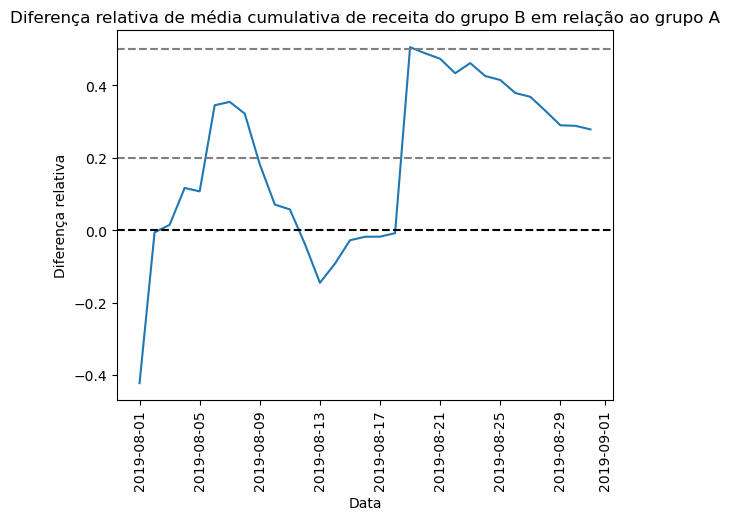

In [13]:
# Juntando as tabelas de dados cumulativos
merged_cumulative_averages = cumulative_average_revenueA[['date', 'average_revenue']].merge(cumulative_average_revenueB[['date', 'average_revenue']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# Criando o gráfico
plt.plot(merged_cumulative_averages['date'], merged_cumulative_averages['average_revenueB'] / merged_cumulative_averages['average_revenueA'] - 1)
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.2, color='grey', linestyle='--')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.title('Diferença relativa de média cumulativa de receita do grupo B em relação ao grupo A')
plt.ylabel('Diferença relativa')
plt.xlabel('Data')
plt.xticks(rotation=90)
plt.show()


Observações: O grupo B demonstra receitas médias melhores do que o grupo A. Apesar dessa diferença oscilar e se inverter no dia 13/08/2019, o grupo B volta a ser maior a partir de 17/08/2019, chegando ao pico de 50% maior que o grupo A. Porém tende a cair em seguida, mas mantendo níveis acima de 20%. A presença de valores de compras altos (outliers) pode estar mascarando o resultado real do teste e interferindo na diferença muito alta entre os grupos em datas específicas.

### Taxa de Conversão Diária Acumulada
Vamos calcular e plotar taxas de conversão diárias acumuladas e sua diferença relativa.

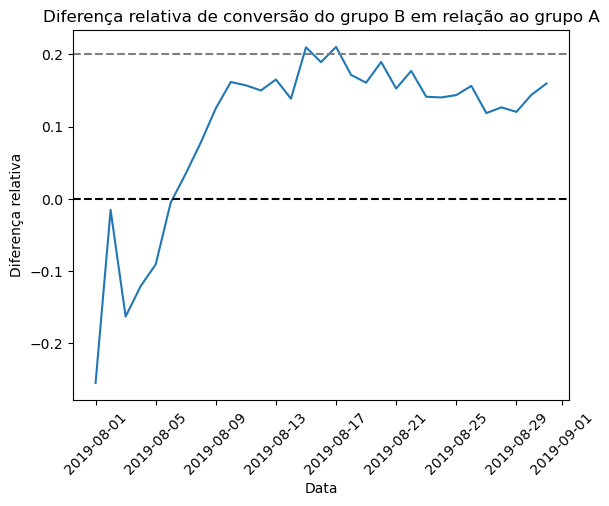

In [14]:
# Juntando as tabelas de dados cumulativos
merged_cumulative_conversions = cumulative_conversionA[['date', 'conversion']].merge(cumulative_conversionB[['date', 'conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# Criando o gráfico
plt.plot(merged_cumulative_conversions['date'], merged_cumulative_conversions['conversionB'] / merged_cumulative_conversions['conversionA'] - 1)
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.2, color='grey', linestyle='--')
plt.title('Diferença relativa de conversão do grupo B em relação ao grupo A')
plt.ylabel('Diferença relativa')
plt.xlabel('Data')
plt.xticks(rotation=45)
plt.show()


Observações: O grupo B demonstra consistentemente taxas de conversão melhores do que o grupo A, e a diferença se estabelece maior após do dia 05/08/2019 e se mantém acima dos 10%. Se houver dados suficientes para atingir o nível de significância, será possível interromper o teste, pois o grupo B é definitivamente melhor do que o A.

### Análise de anomalias
#### Número de Pedidos por Usuário
Vamos plotar dispersão, calcular percentis 90, 95 e 99 para definir limites de anomalias.

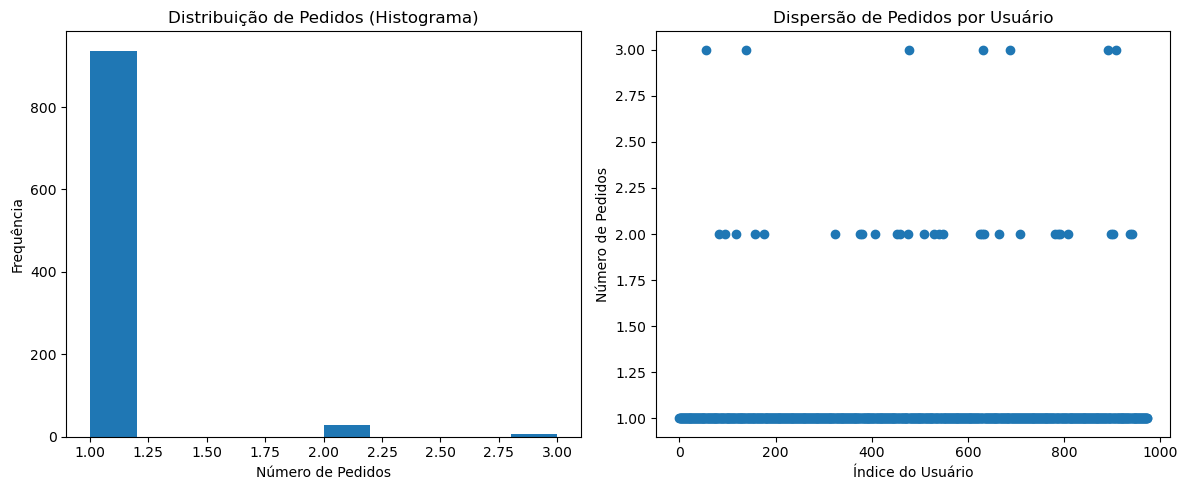

In [24]:
# Preparação dos dados para criação de gráficos - histograma e dispersão
orders_by_user = df_orders_cleaned.drop(['date', 'revenue', 'group'], axis=1).groupby('visitorid', as_index=False).agg({'transactionid': pd.Series.nunique})
orders_by_user.columns = ['visitorid', 'orders']
x_values = pd.Series(range(0, len(orders_by_user)))

# Criando a figura e os eixos (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plotando o Histograma no primeiro eixo (ax1)
ax1.hist(orders_by_user['orders'])
ax1.set_title('Distribuição de Pedidos (Histograma)')
ax1.set_xlabel('Número de Pedidos')
ax1.set_ylabel('Frequência')

# Plotando a Dispersão no segundo eixo (ax2)
ax2.scatter(x_values, orders_by_user['orders'])
ax2.set_title('Dispersão de Pedidos por Usuário')
ax2.set_xlabel('Índice do Usuário')
ax2.set_ylabel('Número de Pedidos')

# Ajustando o layout para evitar sobreposição
plt.tight_layout()

# Exibindo gráficos
plt.show()

Observações: A maioria dos usuários realizou somente um pedido. Poucos usuários realizaram 2 ou 3 pedidos. Agora vamos calcular percentis 90, 95 e 99 para definir limites de anomalias.

In [16]:
# Verificando percentis 90, 95 e 99% para entender anomalias
print(orders_by_user.sort_values(by='orders', ascending=False).head(10))
print(np.percentile(orders_by_user['orders'], [90, 95, 99]))


      visitorid  orders
632  2742574263       3
687  2988190573       3
478  2108163459       3
55    249864742       3
908  3967698036       3
890  3908431265       3
138   611059232       3
157   678354126       2
634  2744017357       2
940  4134830387       2
[1. 1. 2.]


Observações: Menos do que 5% dos usuários fez mais que 1 pedido e menos que 1% fez mais do que 2.
#### Preços dos Pedidos
Vamos plotar dispersão, calcular percentis 90, 95 e 99 para definir limites de anomalias.

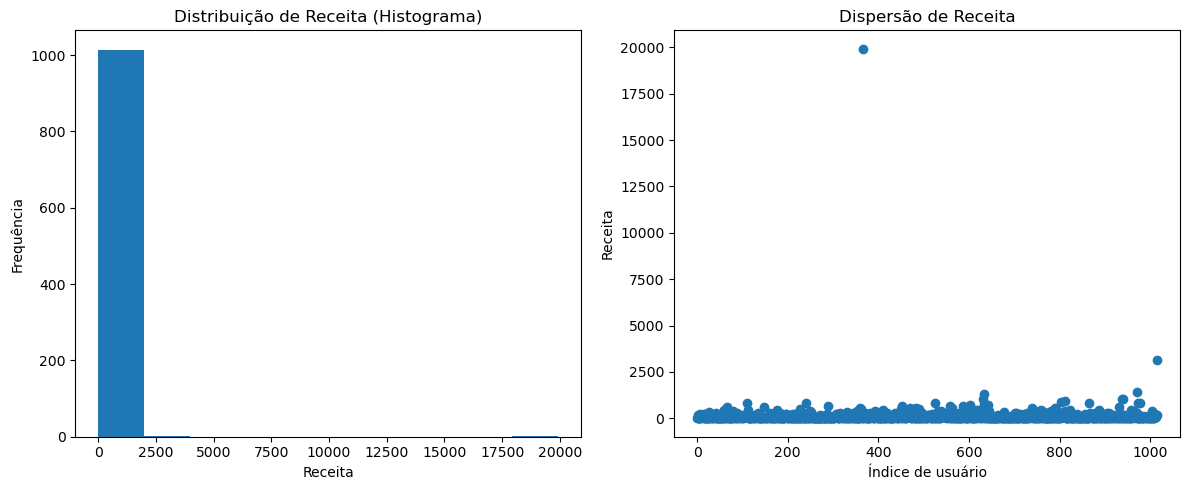

In [17]:
# Preparação dos dados para criação de gráfico de dispersão
xx_values = pd.Series(range(0, len(df_orders_cleaned['revenue'])))

# Criar a figura e os eixos (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plotando o Histograma no primeiro eixo (ax1)
ax1.hist(df_orders_cleaned['revenue'])
ax1.set_title('Distribuição de Receita (Histograma)')
ax1.set_xlabel('Receita')
ax1.set_ylabel('Frequência')

# Plotando a dispersão no segundo eixo (ax2)
ax2.scatter(xx_values, df_orders_cleaned['revenue'])
ax2.set_title('Dispersão de Receita')
ax2.set_xlabel('Índice de usuário')
ax2.set_ylabel('Receita')

# Ajustando o layout para evitar sobreposição
plt.tight_layout()

# Exibindo gráficos
plt.show()


Observações: Só há dois pedidos acima de $ 2.500,00. O restante está abaixo disso. Vamos verificar os percentis para entender de maneira clara.

In [18]:
# Verificando percentis 90, 95 e 99% para entender anomalias
print(df_orders_cleaned.sort_values(by='revenue', ascending=False).head(10))
print(np.percentile(df_orders_cleaned['revenue'], [90, 95, 99]))


      transactionid   visitorid       date  revenue group
425       590470918  1920142716 2019-08-19  19920.4     B
1196     3936777065  2108080724 2019-08-15   3120.1     B
1136      666610489  1307669133 2019-08-13   1425.8     A
744      3668308183   888512513 2019-08-27   1335.6     B
743      3603576309  4133034833 2019-08-09   1050.0     A
1103     1348774318  1164614297 2019-08-12   1025.8     A
1099      316924019   148427295 2019-08-12   1015.9     A
949      1347999392   887908475 2019-08-21    930.0     A
940      2420050534  4003628586 2019-08-08    905.8     B
131      3163614039  2254586615 2019-08-22    830.3     A
[280.8   414.275 830.3  ]


Observações: Menos de 5% dos usuários fizeram compras com valores maiores que $414. Menos que 1% deles fizeram compras com valores superiores a $830.
### Testes Estatísticos
Vamos configurar variáveis e funções: vamos definir alpha = 0.05 e preparar amostras de conversão (pedidos por usuário) e receita para grupos A e B.

In [19]:
# Criando DataFrames de pedidos por usuário para cada grupo
orders_by_usersA = df_orders_cleaned[df_orders_cleaned['group'] == 'A'].groupby('visitorid', as_index=False).agg({'transactionid': pd.Series.nunique})
orders_by_usersB = df_orders_cleaned[df_orders_cleaned['group'] == 'B'].groupby('visitorid', as_index=False).agg({'transactionid': pd.Series.nunique})

# Renomeando colunas
orders_by_usersA.columns = ['visitorid', 'orders']
orders_by_usersB.columns = ['visitorid', 'orders']

# Definindo alfa
alfa = 0.05


#### Significância Estatística da Diferença na Conversão (Dados Brutos)
Realizando Teste Mann-Whitney U, calculando p-value e diferença relativa nos dados brutos, ou seja, dados sem a remoção de anomalias (outliers).

In [20]:
# Declarando variáveis sampleA e sampleB
sampleA = pd.concat(
    [
        orders_by_usersA['orders'],
        pd.Series(0, index=np.arange(df_visits[df_visits['group'] == 'A']['visits'].sum() - len(orders_by_usersA['orders'])),
                  name='orders')
    ],
    axis=0,
)

sampleB = pd.concat(
    [
        orders_by_usersB['orders'],
        pd.Series(0, index=np.arange(df_visits[df_visits['group'] == 'B']['visits'].sum() - len(orders_by_usersB['orders'])),
                  name='orders')
    ],
    axis=0,
)

# Realizando teste de Mann-Whitney U
conversion_pvalue = stats.mannwhitneyu(sampleA, sampleB)[1]
conversion_relation = sampleB.mean() / sampleA.mean() - 1

# Imprimindo resultados
if conversion_pvalue < alfa:
    print(f'Conversão é significativamente diferente entre os grupos (valor-p = {conversion_pvalue:.5f})')
    print(f'Ganho de conversão entre Grupo B comparado ao Grupo A é de: {(conversion_relation * 100):.1f}%')
else:
    print(f'Conversão não é significativamente diferente entre os grupos (valor-p = {conversion_pvalue:.5f})')



Conversão é significativamente diferente entre os grupos (valor-p = 0.01102)
Ganho de conversão entre Grupo B comparado ao Grupo A é de: 16.0%


Observações: O valor-p é menor do que 0.05, então nós rejeitamos a hipótese nula. A análise dos dados brutos mostrou que as taxas de conversão dos grupos possuem diferenças estatísticas significativas. O ganho de conversão relativo para o grupo B, comparado com o grupo A, é 16%. Agora precisamos apenas comparar os volumes médios de pedidos usando os dados brutos, e então comparar as duas métricas novamente com os valores atípicos retirados pela filtragem.
### Significância Estatística da Diferença no Tamanho Médio do Pedido (Dados Brutos)
Realizando Teste Mann-Whitney U, calculaando p-value e diferença relativa.

In [21]:
# Realizando teste estatístico de Mann-Whitney U para receita média por pedido entre os grupos A e B
revenue_average_pvalue = stats.mannwhitneyu(
    df_orders_cleaned[df_orders_cleaned['group'] == 'A']['revenue'],
    df_orders_cleaned[df_orders_cleaned['group'] == 'B']['revenue']
)[1]

revenue_average_relation = df_orders_cleaned[df_orders_cleaned['group'] == 'B']['revenue'].mean() / df_orders_cleaned[df_orders_cleaned['group'] == 'A']['revenue'].mean() - 1

# Imprimindo resultados
if revenue_average_pvalue < alfa:
    print(f'Receita média por pedido é significativamente diferente entre os grupos (valor-p = {revenue_average_pvalue:.5f})')
    print(f'A relação entre a receita média por pedido dos grupos B e A é de {revenue_average_relation:.3f}')
else:
    print(f'Receita média por pedido não é significativamente diferente entre os grupos (valor-p = {revenue_average_pvalue:.5f})')
    print(f'Por mais que a relação entre a receita média por pedido dos grupos B e A seja de {(revenue_average_relation * 100):.1f}%, não há diferença significativa entre os grupos.')


Receita média por pedido não é significativamente diferente entre os grupos (valor-p = 0.86223)
Por mais que a relação entre a receita média por pedido dos grupos B e A seja de 27.8%, não há diferença significativa entre os grupos.


Observação: O valor-p é maior do que 0.05, então não há diferenças estatísticas significativas entre os volumes médios de pedidos dos grupos, mesmo a diferença relativa sendo de 27,8%. Agora vamos analisar os dados removendo as anomalias.
### Significância Estatística da Diferença na Conversão (Dados Filtrados)
Vamos filtrar anomalias (pedidos por usuário e preços de pedidos acima do percentil 99) e repetir teste Mann-Whitney U.

In [22]:
# Criando DataFrame com os outliers (dados acima dos percetis de 99%)
users_with_many_orders = pd.concat([orders_by_usersA[orders_by_usersA['orders'] > 2]['visitorid'], orders_by_usersB[orders_by_usersB['orders'] > 2]['visitorid']], axis=0)
users_with_expensive_orders = df_orders_cleaned[df_orders_cleaned['revenue'] > 830.30]['visitorid']

abnormal_users = pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0).drop_duplicates().sort_values()

# Declarando variáveis sampleA e sampleB filtradas (sem usuários anômalos)
sampleA_filtered = pd.concat([orders_by_usersA[np.logical_not(orders_by_usersA['visitorid'].isin(abnormal_users))]['orders'],
                              pd.Series(0, index=np.arange(df_visits[df_visits['group'] == 'A']['visits'].sum() - len(orders_by_usersA['orders'])),
                                        name='orders')], axis=0)

sampleB_filtered = pd.concat([orders_by_usersB[np.logical_not(orders_by_usersB['visitorid'].isin(abnormal_users))]['orders'],
                              pd.Series(0, index=np.arange(df_visits[df_visits['group'] == 'B']['visits'].sum() - len(orders_by_usersB['orders'])),
                                        name='orders')], axis=0)

# Realizando teste de Mann-Whitney U
conversion_filtered_pvalue = stats.mannwhitneyu(sampleA_filtered, sampleB_filtered)[1]
conversion_filtered_relation = sampleB_filtered.mean() / sampleA_filtered.mean() - 1

# Imprimindo resultados
if conversion_filtered_pvalue < alfa:
    print(f'Conversão é significativamente diferente entre os grupos (valor-p = {conversion_filtered_pvalue:.5f})')
    print(f'Ganho de conversão entre Grupo B comparado ao Grupo A é de: {(conversion_filtered_relation * 100):.1f}%')
else:
    print(f'Conversão não é significativamente diferente entre os grupos (valor-p = {conversion_filtered_pvalue:.5f})')


Conversão é significativamente diferente entre os grupos (valor-p = 0.00702)
Ganho de conversão entre Grupo B comparado ao Grupo A é de: 18.9%


Observação: Assim como ocorreu com os dados brutos, o nível de significância foi atingido. O segmento B é 18,9% melhor do que o segmento A.
### Significância Estatística da Diferença no Tamanho Médio do Pedido (Dados Filtrados)
Vamos repetir teste Mann-Whitney U com dados filtrados.

In [23]:
# Realizando teste estatístico de Mann-Whitney U para receita média por pedido entre os grupos A e B com dados filtrados (sem usuários anômalos)
revenue_average_filtered_pvalue = stats.mannwhitneyu(
    df_orders_cleaned[np.logical_and(df_orders_cleaned['group'] == 'A',
                                    np.logical_not(df_orders_cleaned['visitorid'].isin(abnormal_users)))]['revenue'],
    df_orders_cleaned[np.logical_and(df_orders_cleaned['group'] == 'B',
                                    np.logical_not(df_orders_cleaned['visitorid'].isin(abnormal_users)))]['revenue'])[1]

revenue_average_filtered_relation = df_orders_cleaned[np.logical_and(df_orders_cleaned['group'] == 'B',
                                                                   np.logical_not(df_orders_cleaned['visitorid'].isin(abnormal_users)))]['revenue'].mean() / df_orders_cleaned[np.logical_and(df_orders_cleaned['group'] == 'A',
                                                                                                                                    np.logical_not(df_orders_cleaned['visitorid'].isin(abnormal_users)))]['revenue'].mean() - 1
# Imprimindo resultados
if revenue_average_filtered_pvalue < alfa:
    print(f'Receita média por pedido é significativamente diferente entre os grupos (valor-p = {revenue_average_filtered_pvalue:.5f})')
    print(f'A relação entre a receita média por pedido dos grupos B e A é de {revenue_average_filtered_relation:.3f}')
else:
    print(f'Receita média por pedido não é significativamente diferente entre os grupos (valor-p = {revenue_average_filtered_pvalue:.5f})')
    print(f'Por mais que a relação entre a receita média por pedido dos grupos B e A seja de {(revenue_average_filtered_relation * 100):.1f}%, não há diferença significativa entre os grupos.')


Receita média por pedido não é significativamente diferente entre os grupos (valor-p = 0.82203)
Por mais que a relação entre a receita média por pedido dos grupos B e A seja de -3.2%, não há diferença significativa entre os grupos.


Observação: Mesmo com os dados filtrados, não houve diferença estatística significativa entre os volumes médios de pedidos dos grupos! Isso significa que, mesmo com a redução da variância e a diferença entre os grupos ter se mostrado invertida (dessa vez o Grupo A sendo 3,2% maior que o Grupo B), ainda não apresentou diferença siginificativa, mostrando que os outliers não interferiram no resultado do teste.
## Decisão Final do Teste A/B
### Resumo das Observações
Priorização de Hipóteses
A aplicação dos frameworks ICE e RICE revelou prioridades distintas dependendo da métrica de sucesso.

Pelo framework ICE, a hipótese líder foi a 8 ("Launch a promotion that gives users discounts on their birthdays"), focada em impacto e confiança locais.

Ao aplicar o RICE, que introduz o fator de alcance (Reach), a hipótese 7 ("Add a subscription form to all the main pages") assumiu a liderança absoluta com um score de 112.0. Isso ocorre porque a hipótese 7 afeta todos os usuários do site, maximizando o retorno sobre o esforço investido.

Análise do Teste A/B
Receita e Conversão: Os gráficos de receita acumulada mostraram o Grupo B consistentemente acima do Grupo A. Observou-se um salto expressivo na receita do Grupo B por volta do dia 17/08/2019, o que inicialmente sugeriu uma vantagem competitiva ou a presença de anomalias.

Anomalias: A análise de percentis identificou que pedidos acima de 28.000 ou usuários com mais de 2 pedidos são considerados outliers. A remoção desses dados foi crucial, pois um único pedido de valor extremo no Grupo B estava distorcendo a percepção de receita média.

Resultados Estatísticos: * Conversão: Houve uma diferença estatisticamente significativa na conversão entre os grupos (valor-p < 0.05 tanto em dados brutos quanto filtrados), com o Grupo B apresentando uma performance superior.

Ticket Médio: Não houve diferença estatística significativa no valor médio dos pedidos após a filtragem dos outliers.

### Decisão Final
Decisão: Parar o teste e considerar o Grupo B como líder.

Justificativa: Embora o ticket médio não tenha apresentado alteração significativa, a taxa de conversão do Grupo B é superior à do Grupo A de forma estatisticamente comprovada. No contexto de uma loja online, o aumento na conversão resulta em um volume maior de transações e, consequentemente, em maior receita total acumulada, mesmo que o valor gasto por pedido permaneça estável. Os gráficos de diferença relativa de conversão mostram que o Grupo B estabilizou em um patamar superior, indicando que a vantagem é real e não fruto de flutuações sazonais ou anomalias.

### Sugestões para Testes Futuros
Duração: O teste atual durou um mês. Recomenda-se que testes futuros considerem pelo menos dois ciclos completos de compra (geralmente 14 a 28 dias) para neutralizar efeitos de fim de semana.

Monitoramento Pós-Teste: Após a implementação definitiva da mudança do Grupo B, monitorar o ticket médio nos próximos 30 dias para garantir que não haja uma queda tardia devido a alguma canibalização de produtos.